# Blue Pigment Analysis in Paintings

## Overview

This notebook analyzes blue pigments in artwork and reports:
- **RGB color** of the dominant blue region
- **Object type** (e.g., clothing, sky, background)

## How to Run

### **Option 1: Google Colab (Recommended - Free GPU)**
1. Upload this notebook to [Google Colab](https://colab.research.google.com/)
2. Add HF_TOKEN to Colab Secrets (🔑 icon in left sidebar)
3. Runtime → Change runtime type → GPU (T4)
4. Run cells in order, use **Option 1** for loading images

### **Option 2: Run Locally**
1. Install dependencies: `uv sync`
2. Authenticate HuggingFace (one-time): `huggingface-cli login`
3. Start Jupyter: `jupyter notebook blue_pigment_analysis.ipynb`
4. Run cells in order, use **Option 2** for loading images

## Method

### 1. Image Segmentation
- **Model:** OneFormer (Swin-Large backbone, trained on ADE20K)
- **Why:** Best accuracy (58.0% mIoU) for semantic segmentation with 150 object categories
- **Output:** Each segment labeled (e.g., "clothing", "sky", "wall")

### 2. Dominant Color Extraction
- **Color Space:** HSV instead of RGB
  - **Why HSV:** Handles lighting variations in paintings better
  - Example: Highlights, shadows, and midtones of the same "blue robe" are grouped together
- **Method:** Quantization (binning) to group similar colors
  - Hue: 18 bins (distinguishes blue from cyan)
  - Saturation: 3 bins (tolerant to intensity variations)
  - Value: 3 bins (tolerant to brightness from lighting)
- **Output:** Most common color in each segment

### 3. Blue Detection
- **Definition:** Hue range 180-270° (cyan to violet)
- **Selection:** Largest blue segment by pixel area
- **Output:** RGB color + semantic label (e.g., "rgb(100,120,180), clothing")

## Model Details

**OneFormer** ([Jain et al., CVPR 2023](https://arxiv.org/abs/2211.06220)):
- Universal architecture for semantic/instance/panoptic segmentation
- Task-conditioned with query-text contrastive learning
- State-of-the-art on ADE20K benchmark (150 semantic classes)
- HuggingFace: `shi-labs/oneformer_ade20k_swin_large`

## Setup

In [ ]:
# Install required packages (for Colab)
!pip install -q transformers torch pillow numpy matplotlib

In [1]:
# Imports
import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from pathlib import Path
from transformers import OneFormerProcessor, OneFormerForUniversalSegmentation
import warnings
warnings.filterwarnings('ignore')

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

PyTorch version: 2.10.0
CUDA available: False


In [2]:
# Setup device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Using device: cpu


## HuggingFace Authentication (Colab Only)

In [9]:
# For Colab: Set HF_TOKEN from secrets
# For Local: Skip this cell (already authenticated via huggingface-cli)

try:
    from google.colab import userdata
    import os
    os.environ['HF_TOKEN'] = userdata.get('HF_TOKEN')
    print("HuggingFace token loaded from Colab secrets")
except:
    print("Running locally - using huggingface-cli authentication")

Running locally - using huggingface-cli authentication


## Load Images

### Option 1: For Google Colab (Upload Images)

In [ ]:
# Run this cell if using Colab
from google.colab import files

print("Please upload your painting images:")
uploaded = files.upload()
image_paths = list(uploaded.keys())
print(f"\nUploaded {len(image_paths)} images: {image_paths}")

### Option 2: For Local (Load from ./images folder)

In [3]:
# Run this cell if using locally
image_folder = Path('./images')
image_paths = [str(p) for p in image_folder.glob('*.jpeg')]
image_paths += [str(p) for p in image_folder.glob('*.jpg')]
image_paths += [str(p) for p in image_folder.glob('*.png')]
print(f"Found {len(image_paths)} images: {image_paths}")

Found 2 images: ['images/chinese_portrait.jpeg', 'images/american_portrait.jpeg']


## Load Model

In [4]:
# Load OneFormer model (downloads ~1GB on first run, then cached)
print("Loading OneFormer model...")

model_name = "shi-labs/oneformer_ade20k_swin_large"
processor = OneFormerProcessor.from_pretrained(model_name)
model = OneFormerForUniversalSegmentation.from_pretrained(model_name).to(device)

print("Model loaded successfully!")

Loading OneFormer model...


Loading weights:   0%|          | 0/826 [00:00<?, ?it/s]

Model loaded successfully!


## Test Segmentation (SAM2)

We use **SAM2** (Segment Anything Model 2) for class-agnostic segmentation: it finds all visually distinct regions in the image without predefined categories. Each region gets a segment ID; semantic labels can be added later (e.g. with a VLM).

In [4]:
# Load test image
test_image_path = image_paths[0]
print(f"Testing segmentation on: {test_image_path}")

test_image = Image.open(test_image_path).convert('RGB')

# SAM2: automatic mask generation (class-agnostic, discovers all regions)
from transformers import pipeline

sam2_device = 0 if torch.cuda.is_available() else -1
generator = pipeline(
    "mask-generation",
    model="facebook/sam2.1-hiera-large",
    device=sam2_device,
)

outputs = generator(test_image, points_per_batch=64)

# Build single segmentation map from SAM2 masks
raw_masks = outputs["masks"]
if isinstance(raw_masks, list):
    masks = np.stack([np.asarray(m) for m in raw_masks])
else:
    masks = np.asarray(raw_masks)
if masks.ndim == 2:
    masks = masks[np.newaxis, ...]
n_masks = masks.shape[0]
h, w = masks.shape[1], masks.shape[2]

# Resize masks to image size if needed
if (h, w) != test_image.size[::-1]:
    masks_resized = np.zeros((n_masks, test_image.size[1], test_image.size[0]), dtype=bool)
    for i in range(n_masks):
        masks_resized[i] = np.array(
            Image.fromarray(masks[i].astype(np.uint8)).resize(
                (test_image.size[0], test_image.size[1]), Image.NEAREST
            ),
            dtype=bool,
        )
    masks = masks_resized
    h, w = masks.shape[1], masks.shape[2]

# Assign each pixel to one segment (later masks overwrite overlapping areas)
segmentation = np.zeros((h, w), dtype=np.int32)
for idx in range(n_masks):
    segmentation[masks[idx]] = idx + 1

# Labels: segment IDs (semantic labels can be added later with VLM/CLIP)
labels = {0: "background"}
labels.update({i + 1: f"segment_{i + 1}" for i in range(n_masks)})

print(f"Segmentation completed! SAM2 found {n_masks} regions.")

Testing segmentation on: images/chinese_portrait.jpeg


Loading weights:   0%|          | 0/741 [00:00<?, ?it/s]

Segmentation completed! SAM2 found 19 regions.


In [5]:
# Analyze segments
unique_classes = np.unique(segmentation)
print(f"\nFound {len(unique_classes)} unique segments:\n")

segment_info = []
for class_id in unique_classes:
    mask = segmentation == class_id
    area = mask.sum()
    label = labels[class_id]
    percentage = (area / mask.size) * 100
    segment_info.append((class_id, label, area, percentage))
    print(f"  {class_id:3d}: {label:25s} - {area:8,} pixels ({percentage:5.2f}%)")

# Sort by area to see largest segments
print("\nTop 10 largest segments:")
for class_id, label, area, percentage in sorted(segment_info, key=lambda x: x[2], reverse=True)[:10]:
    print(f"  {class_id:3d}: {label:25s} - {area:8,} pixels ({percentage:5.2f}%)")


Found 20 unique segments:

    0: background                - 2,111,204 pixels (52.30%)
    1: segment_1                 - 1,750,227 pixels (43.36%)
    2: segment_2                 -       35 pixels ( 0.00%)
    3: segment_3                 -   19,351 pixels ( 0.48%)
    4: segment_4                 -    3,948 pixels ( 0.10%)
    5: segment_5                 -    4,681 pixels ( 0.12%)
    6: segment_6                 -    4,062 pixels ( 0.10%)
    7: segment_7                 -    5,847 pixels ( 0.14%)
    8: segment_8                 -    4,516 pixels ( 0.11%)
    9: segment_9                 -        6 pixels ( 0.00%)
   10: segment_10                -    4,681 pixels ( 0.12%)
   11: segment_11                -   48,393 pixels ( 1.20%)
   12: segment_12                -    2,436 pixels ( 0.06%)
   13: segment_13                -    6,140 pixels ( 0.15%)
   14: segment_14                -    3,536 pixels ( 0.09%)
   15: segment_15                -        8 pixels ( 0.00%)
   16: seg

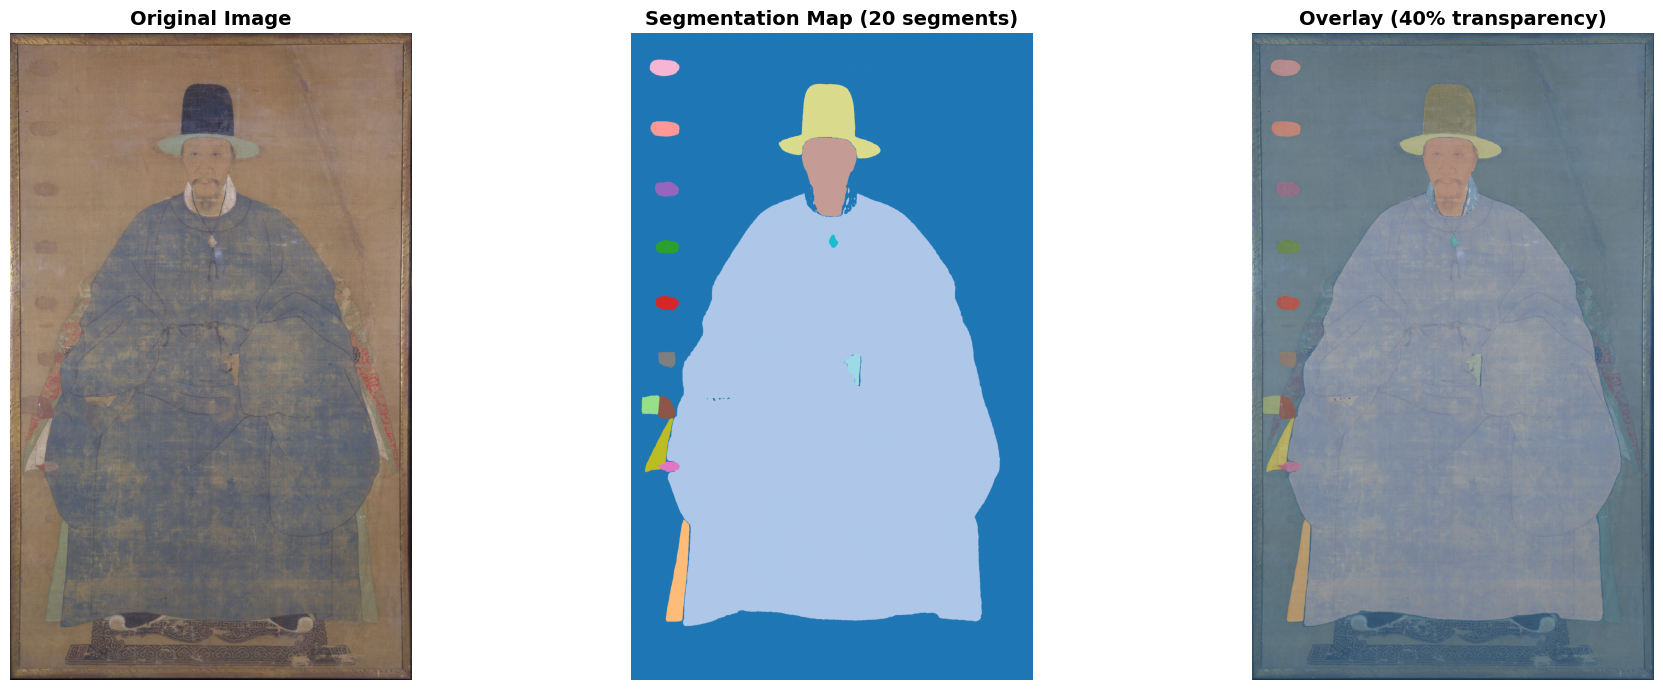


If the segmentation looks correct (multiple distinct regions), we can proceed.
If it's mostly one color, there may be an issue with the model.


In [6]:
# Visualize segmentation
fig, axes = plt.subplots(1, 3, figsize=(20, 7))

# Original image
axes[0].imshow(test_image)
axes[0].set_title('Original Image', fontsize=14, fontweight='bold')
axes[0].axis('off')

# Segmentation map with colors
axes[1].imshow(segmentation, cmap='tab20')
axes[1].set_title(f'Segmentation Map ({len(unique_classes)} segments)', fontsize=14, fontweight='bold')
axes[1].axis('off')

# Overlay
axes[2].imshow(test_image)
axes[2].imshow(segmentation, cmap='tab20', alpha=0.4)
axes[2].set_title('Overlay (40% transparency)', fontsize=14, fontweight='bold')
axes[2].axis('off')

plt.tight_layout()
plt.show()

print("\nIf the segmentation looks correct (multiple distinct regions), we can proceed.")
print("If it's mostly one color, there may be an issue with the model.")

## Helper Functions

In [ ]:
def rgb_to_hsv(rgb):
    """
    Convert RGB (0-255) to HSV (H: 0-360, S: 0-100, V: 0-100)

    Args:
        rgb: numpy array of shape (N, 3) or (3,)

    Returns:
        hsv: numpy array of same shape
    """
    rgb = np.asarray(rgb, dtype=np.float32) / 255.0

    if rgb.ndim == 1:
        rgb = rgb.reshape(1, -1)
        squeeze = True
    else:
        squeeze = False

    r, g, b = rgb[:, 0], rgb[:, 1], rgb[:, 2]

    maxc = np.maximum(np.maximum(r, g), b)
    minc = np.minimum(np.minimum(r, g), b)
    v = maxc

    deltac = maxc - minc
    s = np.where(maxc != 0, deltac / maxc, 0)

    rc = np.where(deltac != 0, (maxc - r) / deltac, 0)
    gc = np.where(deltac != 0, (maxc - g) / deltac, 0)
    bc = np.where(deltac != 0, (maxc - b) / deltac, 0)

    h = np.zeros_like(v)
    h = np.where((maxc == r), bc - gc, h)
    h = np.where((maxc == g), 2.0 + rc - bc, h)
    h = np.where((maxc == b), 4.0 + gc - rc, h)
    h = np.where((minc == maxc), 0, h)

    h = (h / 6.0) % 1.0
    h = h * 360  # Convert to degrees
    s = s * 100  # Convert to percentage
    v = v * 100  # Convert to percentage

    hsv = np.stack([h, s, v], axis=-1)

    if squeeze:
        hsv = hsv.squeeze(0)

    return hsv


def hsv_to_rgb(hsv):
    """
    Convert HSV (H: 0-360, S: 0-100, V: 0-100) to RGB (0-255)

    Args:
        hsv: numpy array of shape (3,) or (N, 3)

    Returns:
        rgb: numpy array of same shape with values 0-255
    """
    hsv = np.asarray(hsv, dtype=np.float32)

    if hsv.ndim == 1:
        hsv = hsv.reshape(1, -1)
        squeeze = True
    else:
        squeeze = False

    h = hsv[:, 0] / 360.0  # Normalize to 0-1
    s = hsv[:, 1] / 100.0
    v = hsv[:, 2] / 100.0

    i = (h * 6.0).astype(int)
    f = (h * 6.0) - i
    p = v * (1.0 - s)
    q = v * (1.0 - s * f)
    t = v * (1.0 - s * (1.0 - f))
    i = i % 6

    rgb = np.zeros_like(hsv)

    conditions = [
        i == 0, i == 1, i == 2, i == 3, i == 4, i == 5
    ]

    choices_r = [v, q, p, p, t, v]
    choices_g = [t, v, v, q, p, p]
    choices_b = [p, p, t, v, v, q]

    rgb[:, 0] = np.select(conditions, choices_r)
    rgb[:, 1] = np.select(conditions, choices_g)
    rgb[:, 2] = np.select(conditions, choices_b)

    rgb = (rgb * 255).astype(int)

    if squeeze:
        rgb = rgb.squeeze(0)

    return rgb


def get_dominant_color_hsv(image, mask, hue_bins=18, sat_bins=3, val_bins=3):
    """
    Get dominant color in a segment using HSV quantization.

    Args:
        image: RGB image array (H, W, 3)
        mask: Boolean mask for segment (H, W)
        hue_bins: Number of hue bins (default 18 = 20° per bin)
        sat_bins: Number of saturation bins (default 3 = 33% per bin)
        val_bins: Number of value bins (default 3 = 33% per bin)

    Returns:
        rgb: Dominant color as (R, G, B) tuple
        confidence: Percentage of pixels with this color
    """
    # Get pixels in segment
    segment_pixels = image[mask]  # Shape: (N, 3)

    if len(segment_pixels) == 0:
        return (0, 0, 0), 0.0

    # Convert to HSV
    hsv_pixels = rgb_to_hsv(segment_pixels)

    # Quantize each channel
    h_quantized = (hsv_pixels[:, 0] // (360 / hue_bins)) * (360 / hue_bins)
    s_quantized = (hsv_pixels[:, 1] // (100 / sat_bins)) * (100 / sat_bins)
    v_quantized = (hsv_pixels[:, 2] // (100 / val_bins)) * (100 / val_bins)

    # Combine quantized values
    quantized_hsv = np.stack([h_quantized, s_quantized, v_quantized], axis=1)

    # Find most common quantized color
    unique_colors, counts = np.unique(quantized_hsv, axis=0, return_counts=True)
    dominant_idx = counts.argmax()
    dominant_hsv = unique_colors[dominant_idx]
    confidence = counts[dominant_idx] / len(segment_pixels)

    # Convert back to RGB
    dominant_rgb = hsv_to_rgb(dominant_hsv)

    return tuple(dominant_rgb), confidence


def is_blue(rgb, hue_range=(180, 270)):
    """
    Check if RGB color is blue based on HSV hue range.

    Args:
        rgb: (R, G, B) tuple
        hue_range: (min, max) hue in degrees (default: 180-270° = cyan to violet)

    Returns:
        bool: True if color is blue
    """
    hsv = rgb_to_hsv(np.array(rgb))
    hue = hsv[0]
    saturation = hsv[1]

    # Blue if hue in range and not too gray (saturation > 15%)
    return hue_range[0] <= hue <= hue_range[1] and saturation > 15


print("Helper functions loaded.")

Helper functions loaded.


Exception in thread Thread-auto_conversion:
Traceback (most recent call last):
  File "/Volumes/yjbolt/projects/pigment-culture/.venv/lib/python3.12/site-packages/httpx/_transports/default.py", line 101, in map_httpcore_exceptions
    yield
  File "/Volumes/yjbolt/projects/pigment-culture/.venv/lib/python3.12/site-packages/httpx/_transports/default.py", line 250, in handle_request
    resp = self._pool.handle_request(req)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Volumes/yjbolt/projects/pigment-culture/.venv/lib/python3.12/site-packages/httpcore/_sync/connection_pool.py", line 256, in handle_request
    raise exc from None
  File "/Volumes/yjbolt/projects/pigment-culture/.venv/lib/python3.12/site-packages/httpcore/_sync/connection_pool.py", line 236, in handle_request
    response = connection.handle_request(
               ^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Volumes/yjbolt/projects/pigment-culture/.venv/lib/python3.12/site-packages/httpcore/_sync/connection.py", line 103, in 

## Segmentation & Analysis Functions

In [6]:
def segment_image(image_path, model, processor, device):
    """
    Segment an image using OneFormer.

    Args:
        image_path: Path to image file
        model: OneFormer model
        processor: OneFormer processor
        device: torch device

    Returns:
        image: PIL Image
        segmentation: Segmentation map (H, W) with class IDs
        labels: List of class labels
    """
    # Load image
    image = Image.open(image_path).convert('RGB')

    # Process image for semantic segmentation
    inputs = processor(images=image, task_inputs=["semantic"], return_tensors="pt")
    inputs = {k: v.to(device) for k, v in inputs.items()}

    # Run model
    with torch.no_grad():
        outputs = model(**inputs)

    # Post-process to get segmentation map
    predicted_map = processor.post_process_semantic_segmentation(
        outputs, target_sizes=[image.size[::-1]]
    )[0]

    segmentation = predicted_map.cpu().numpy()

    # Get unique labels
    labels = model.config.id2label

    return image, segmentation, labels


def analyze_blue_pigment(image_path, model, processor, device):
    """
    Main pipeline: Segment image, find dominant blue, return RGB + label.

    Args:
        image_path: Path to image file
        model: OneFormer model
        processor: OneFormer processor
        device: torch device

    Returns:
        dict with keys:
            - rgb: Dominant blue RGB as tuple
            - object: Semantic label
            - area: Pixel area of blue region
            - confidence: Color confidence (0-1)
            - all_segments: List of all segment info
    """
    print(f"Processing {image_path}...")

    # Step 1: Segment image
    image, segmentation, labels = segment_image(image_path, model, processor, device)
    image_array = np.array(image)

    # Step 2: Analyze each segment
    unique_classes = np.unique(segmentation)
    segment_data = []

    print(f"  Found {len(unique_classes)} segments")

    for class_id in unique_classes:
        mask = segmentation == class_id
        area = mask.sum()
        label = labels[class_id]

        # Get dominant color in this segment
        dominant_rgb, confidence = get_dominant_color_hsv(image_array, mask)

        segment_data.append({
            'class_id': int(class_id),
            'label': label,
            'dominant_rgb': dominant_rgb,
            'area': int(area),
            'confidence': float(confidence),
            'is_blue': is_blue(dominant_rgb)
        })

    # Step 3: Filter blue segments
    blue_segments = [s for s in segment_data if s['is_blue']]

    print(f"  Found {len(blue_segments)} blue segments")

    # Step 4: Find largest blue segment
    if not blue_segments:
        return {
            'rgb': None,
            'object': None,
            'area': 0,
            'confidence': 0.0,
            'all_segments': segment_data,
            'image': image,
            'segmentation': segmentation
        }

    main_blue = max(blue_segments, key=lambda s: s['area'])

    print(f"  Main blue: {main_blue['label']} - RGB{main_blue['dominant_rgb']}")

    return {
        'rgb': main_blue['dominant_rgb'],
        'object': main_blue['label'],
        'area': main_blue['area'],
        'confidence': main_blue['confidence'],
        'all_segments': segment_data,
        'image': image,
        'segmentation': segmentation,
        'blue_segments': blue_segments
    }


print("Analysis functions loaded.")

Analysis functions loaded.


## Visualization Functions

In [ ]:
def visualize_results(result):
    """
    Visualize analysis results.

    Args:
        result: Output from analyze_blue_pigment()
    """
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    # Original image
    axes[0].imshow(result['image'])
    axes[0].set_title('Original Image', fontsize=14)
    axes[0].axis('off')

    # Segmentation map
    axes[1].imshow(result['segmentation'], cmap='tab20')
    axes[1].set_title('Segmentation Map', fontsize=14)
    axes[1].axis('off')

    # Blue segments highlighted
    if result['rgb'] is not None:
        # Create overlay
        overlay = np.array(result['image']).copy()

        # Highlight all blue segments
        for seg in result.get('blue_segments', []):
            mask = result['segmentation'] == seg['class_id']
            overlay[mask] = overlay[mask] * 0.5 + np.array([0, 255, 255]) * 0.5

        axes[2].imshow(overlay.astype(np.uint8))
        axes[2].set_title('Blue Regions Highlighted', fontsize=14)
    else:
        axes[2].imshow(result['image'])
        axes[2].set_title('No Blue Found', fontsize=14)
    axes[2].axis('off')

    plt.tight_layout()
    plt.show()

    # Print results
    print("\n" + "="*50)
    print("RESULTS")
    print("="*50)

    if result['rgb'] is not None:
        print(f"Dominant Blue RGB: {result['rgb']}")
        print(f"Object Type: {result['object']}")
        print(f"Area: {result['area']:,} pixels")
        print(f"Color Confidence: {result['confidence']:.1%}")

        # Show color swatch
        fig, ax = plt.subplots(1, 1, figsize=(3, 1))
        color_array = np.ones((100, 300, 3), dtype=np.uint8) * np.array(result['rgb'])
        ax.imshow(color_array)
        ax.set_title(f"Dominant Blue: RGB{result['rgb']}", fontsize=12)
        ax.axis('off')
        plt.show()
    else:
        print("No blue regions found in image.")

    # Show all blue segments
    blue_segs = result.get('blue_segments', [])
    if len(blue_segs) > 1:
        print(f"\nAll blue segments ({len(blue_segs)}):")
        for i, seg in enumerate(sorted(blue_segs, key=lambda s: s['area'], reverse=True)):
            print(f"  {i+1}. {seg['label']}: RGB{seg['dominant_rgb']} ({seg['area']:,} pixels)")


print("Visualization functions loaded.")

Visualization functions loaded.


## Run Analysis

Process uploaded images:


Analyzing: images/chinese_portrait.jpeg
Processing images/chinese_portrait.jpeg...
  Found 2 segments
  Found 0 blue segments


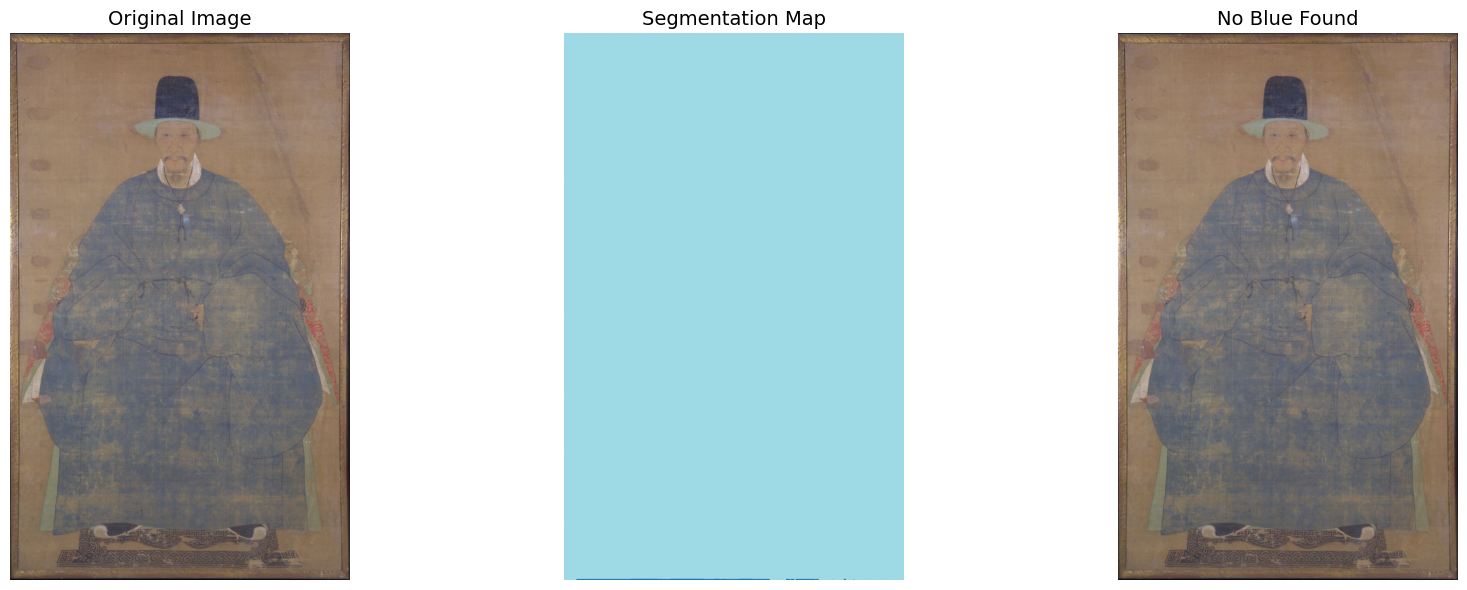


RESULTS
No blue regions found in image.

Analyzing: images/american_portrait.jpeg
Processing images/american_portrait.jpeg...
  Found 2 segments
  Found 0 blue segments


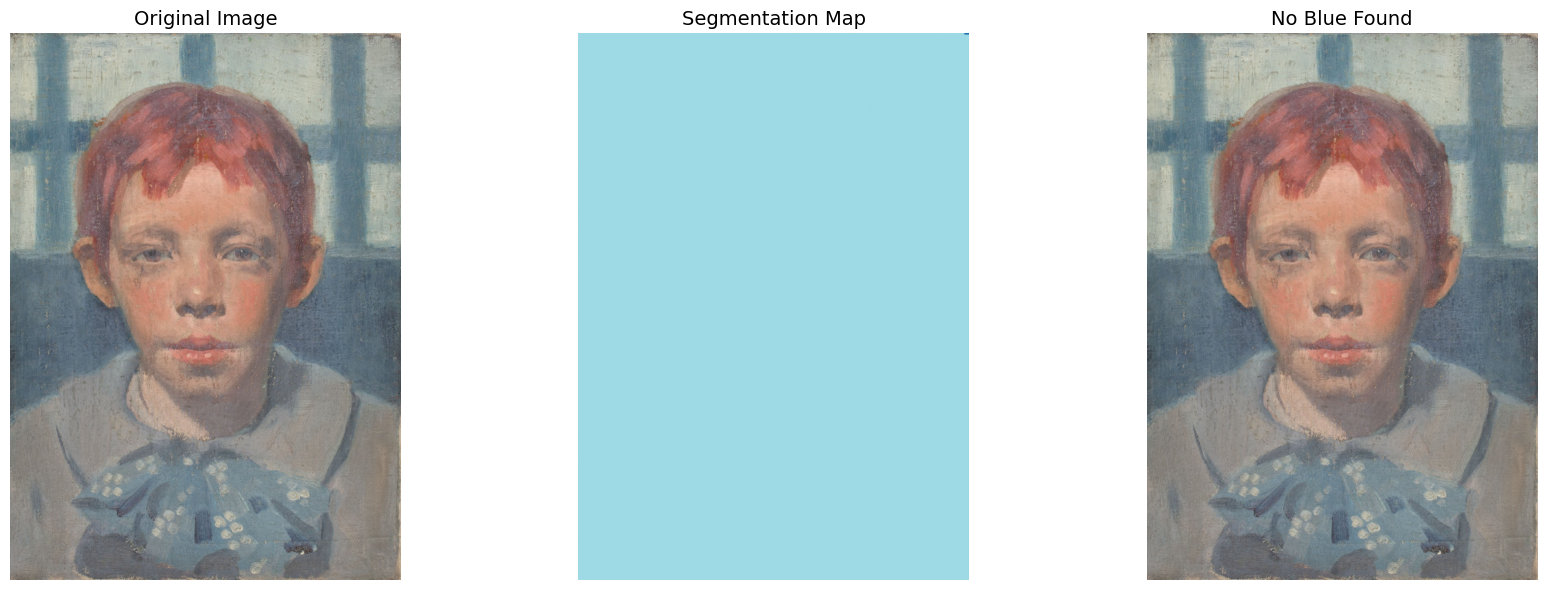


RESULTS
No blue regions found in image.

All images processed!


In [8]:
# Process each uploaded image
results = {}

for image_path in image_paths:
    print(f"\n{'='*60}")
    print(f"Analyzing: {image_path}")
    print(f"{'='*60}")

    result = analyze_blue_pigment(image_path, model, processor, device)
    results[image_path] = result

    # Visualize
    visualize_results(result)

print("\n" + "="*60)
print("All images processed!")
print("="*60)

## Export Results

Save results to CSV:

In [9]:
import pandas as pd

# Create summary DataFrame
summary_data = []

for image_path, result in results.items():
    if result['rgb'] is not None:
        r, g, b = result['rgb']
        summary_data.append({
            'image': image_path,
            'object': result['object'],
            'R': r,
            'G': g,
            'B': b,
            'area_pixels': result['area'],
            'color_confidence': result['confidence']
        })
    else:
        summary_data.append({
            'image': image_path,
            'object': 'No blue found',
            'R': None,
            'G': None,
            'B': None,
            'area_pixels': 0,
            'color_confidence': 0.0
        })

df = pd.DataFrame(summary_data)

# Display
print("\nSummary Results:")
print(df.to_string(index=False))

# Save to CSV
csv_filename = 'blue_pigment_results.csv'
df.to_csv(csv_filename, index=False)
print(f"\nResults saved to {csv_filename}")


Summary Results:
                        image        object    R    G    B  area_pixels  color_confidence
 images/chinese_portrait.jpeg No blue found None None None            0               0.0
images/american_portrait.jpeg No blue found None None None            0               0.0

Results saved to blue_pigment_results.csv


### Download Results (Colab Only)

In [ ]:
# Run this cell only if using Colab to download the CSV file
files.download(csv_filename)